# Speech Processing Lab 3
#### Dewang Choudhary
#### BL.EN.U4AIE23145

## Objective 1

To identify, segment, and visualize different phoneme classes in a recorded speech signal and to analyze voiced and unvoiced regions using waveform-level inspection.

Record the sentence: *"She judged the blue pen, put it on the table, and quietly whispered yes."*

Using the procedures implemented in Lab-2, perform the following steps:
1. Load and preprocess the recorded speech signal.
2. Automatically segment the speech into phoneme-level units (similar to previous lab).
3. Plot the time-domain waveform corresponding to each extracted phoneme.
4. For every phoneme segment:
   - Identify its phoneme category (vowel, plosive, fricative, affricate, semivowel, diphthong, or whisper segment).
   - Label the phoneme accordingly.
5. Select and extract:
   - One voiced phoneme segment
   - One unvoiced phoneme segment
6. Compare the waveform characteristics of the voiced and unvoiced segments and explain the observed differences based on:
   - Periodicity
   - Amplitude patterns
   - Presence or absence of noise-like structure

## 1. Library Imports

In [14]:
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import librosa

from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

import warnings
warnings.filterwarnings("ignore")

## 2. Load Pre-trained Wav2Vec2 Model

In [15]:
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")
model.eval()

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder)

## 3. Load and Preprocess Speech Signal

In [16]:
import os
import librosa
import torch

audio_filename = "voice1.wav"


if not os.path.exists(audio_filename):
    print(f"Error: '{audio_filename}' not found. Please upload your recorded audio file to the Colab files tab.")
else:
    data, sample_rate = librosa.load(audio_filename, sr=None, mono=False)

    waveform = torch.from_numpy(data).float()

    if len(waveform.shape) == 1:
        waveform = waveform.unsqueeze(0)

    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    waveform = waveform / torch.max(torch.abs(waveform))

    print("Sampling Rate:", sample_rate)

Sampling Rate: 48000


## 4. Plot Original Speech Waveform

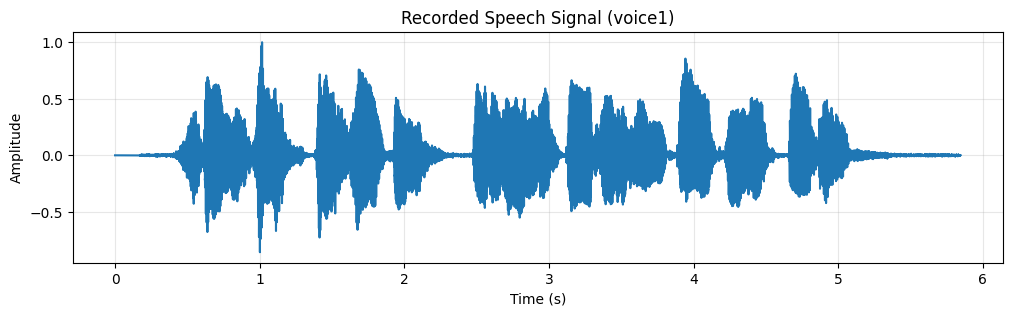

In [17]:
time_axis = np.arange(waveform.shape[1]) / sample_rate

plt.figure(figsize=(12,3))
plt.plot(time_axis, waveform[0].numpy())
plt.title("Recorded Speech Signal (voice1)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.show()

## 5. Recognize Phonemes using Wav2Vec2

In [18]:
target_sampling_rate = 16000

if sample_rate != target_sampling_rate:
    waveform_np = waveform[0].numpy()
    waveform_resampled = librosa.resample(waveform_np, orig_sr=sample_rate, target_sr=target_sampling_rate)
    input_sr = target_sampling_rate
else:
    waveform_resampled = waveform[0].numpy()
    input_sr = sample_rate

input_values = processor(
    waveform_resampled,
    sampling_rate=input_sr,
    return_tensors="pt"
).input_values

with torch.no_grad():
    logits = model(input_values).logits

predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.decode(predicted_ids[0])

print("Recognized Phoneme Sequence:")
print(transcription)

Recognized Phoneme Sequence:
SHE JUDGED THE BLUE PEN PUT IT ON THE TABLE AND QUIETLY WHISPERDIUS


## 6. Estimate Phoneme Time Intervals

In [19]:
predicted_tokens = predicted_ids[0].numpy()
time_step = waveform.shape[1] / logits.shape[1] / sample_rate

phoneme_intervals = []
current_phoneme = None
start_idx = 0

for idx, token_id in enumerate(predicted_tokens):
    phoneme = processor.decode([token_id]).strip()

    if phoneme and phoneme != current_phoneme:
        if current_phoneme is not None:
            phoneme_intervals.append({
                "phoneme": current_phoneme,
                "start_sample": int(start_idx * time_step * sample_rate),
                "end_sample": int(idx * time_step * sample_rate)
            })
        current_phoneme = phoneme
        start_idx = idx

if current_phoneme is not None:
    phoneme_intervals.append({
        "phoneme": current_phoneme,
        "start_sample": int(start_idx * time_step * sample_rate),
        "end_sample": waveform.shape[1]
    })

print(f"Detected {len(phoneme_intervals)} phoneme segments")

Detected 55 phoneme segments


## 7. Phoneme Category Classification

In [20]:
phoneme_categories = {
    'A':'vowel', 'E':'vowel', 'I':'vowel', 'O':'vowel', 'U':'vowel',
    'P':'plosive', 'B':'plosive', 'T':'plosive', 'D':'plosive', 'K':'plosive', 'G':'plosive',
    'F':'fricative', 'S':'fricative', 'H':'fricative', 'Z':'fricative',
    'Y':'semivowel', 'W':'semivowel', 'L':'semivowel', 'R':'semivowel'
}

for p in phoneme_intervals:
    p["category"] = phoneme_categories.get(p["phoneme"].upper(), "whisper/other")

## 8. Extract & Plot Each Phoneme Waveform

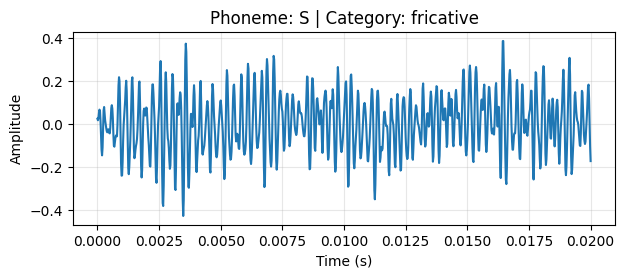

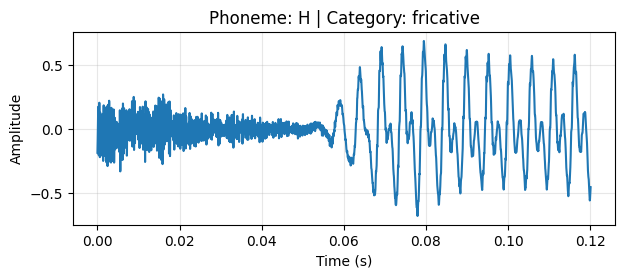

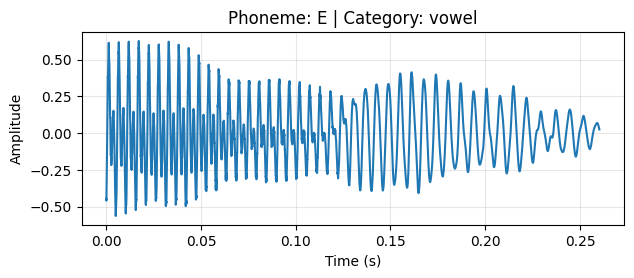

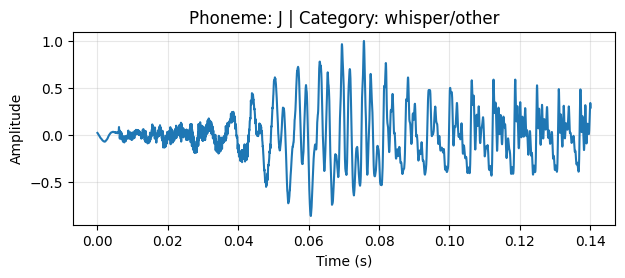

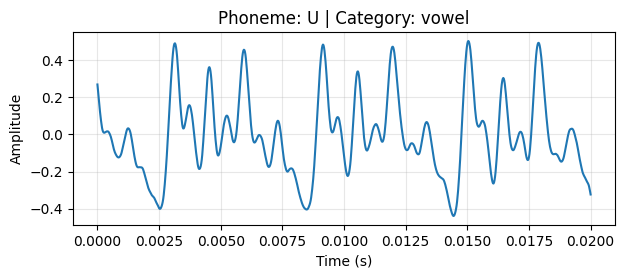

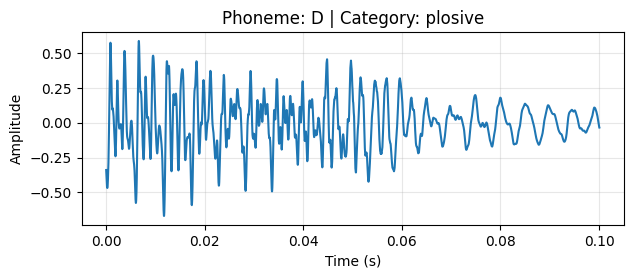

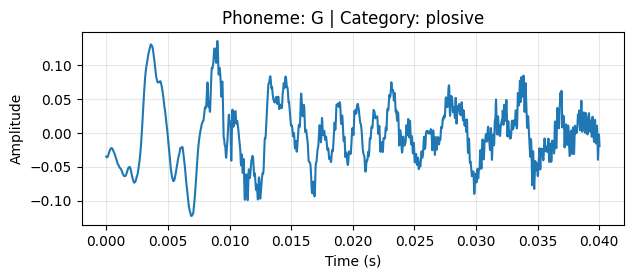

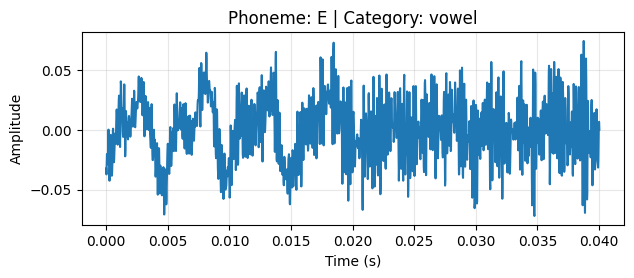

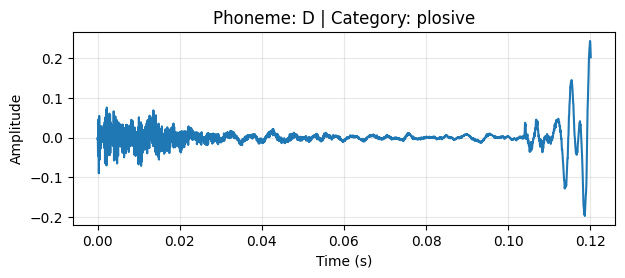

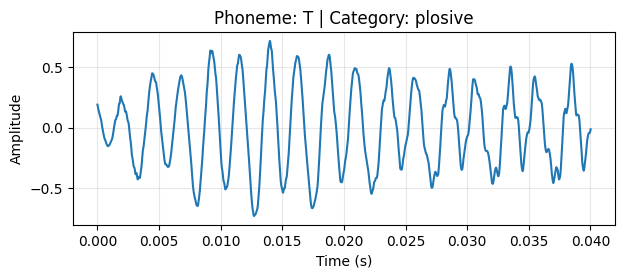

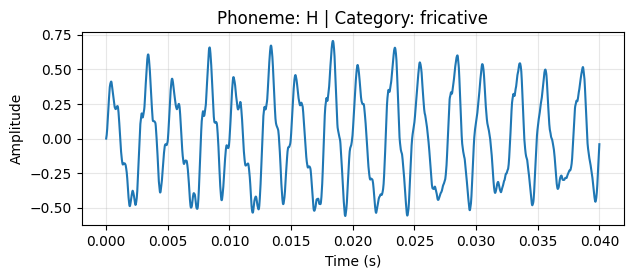

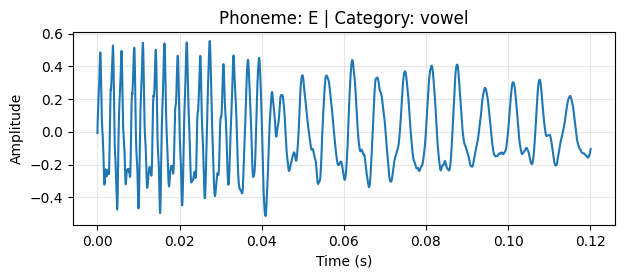

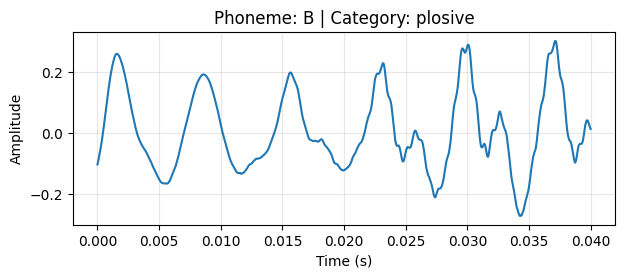

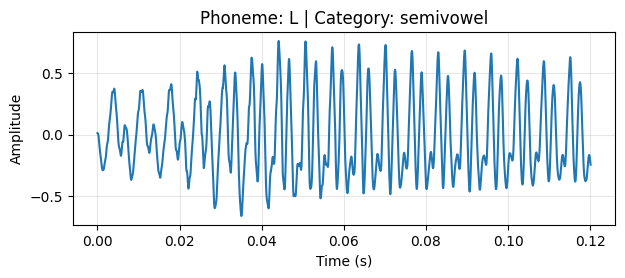

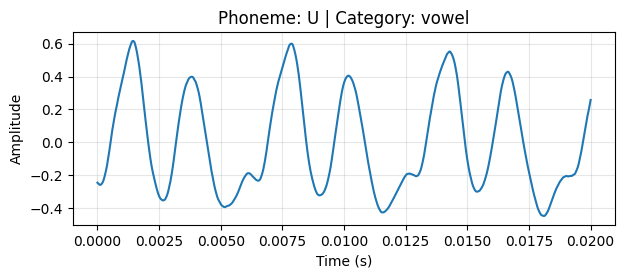

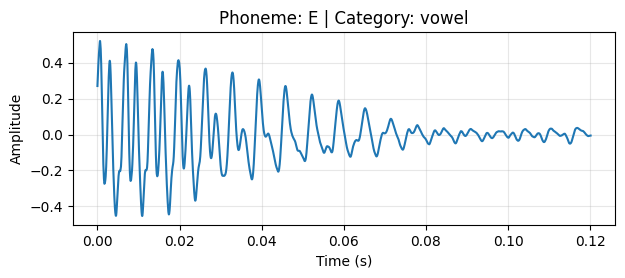

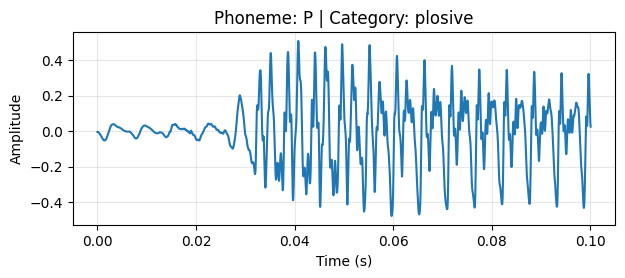

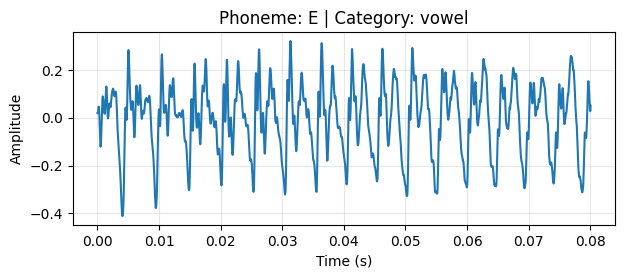

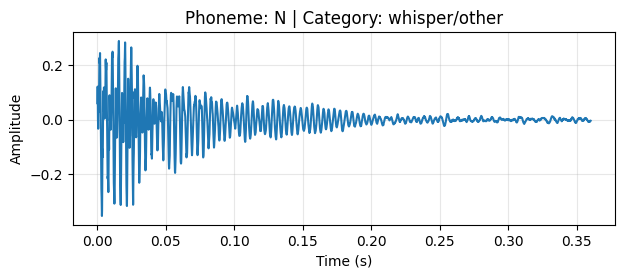

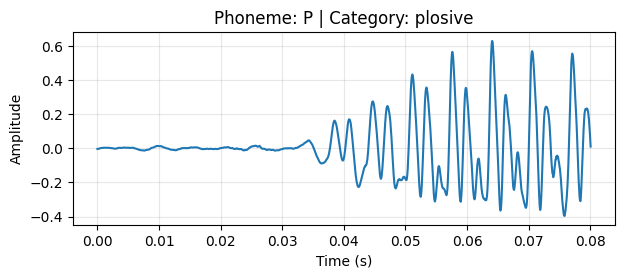

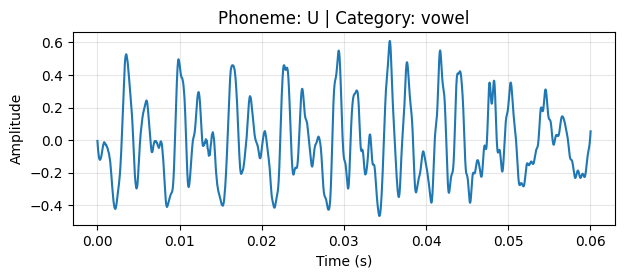

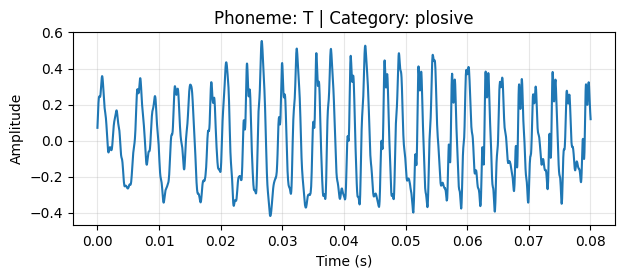

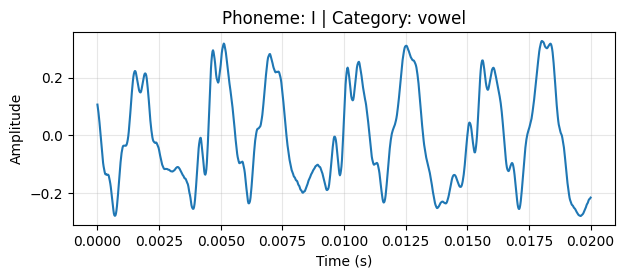

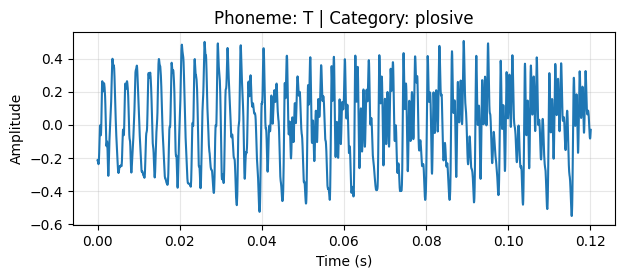

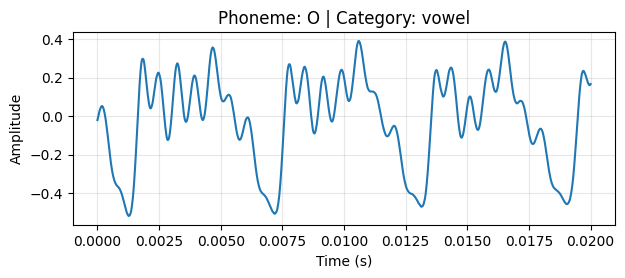

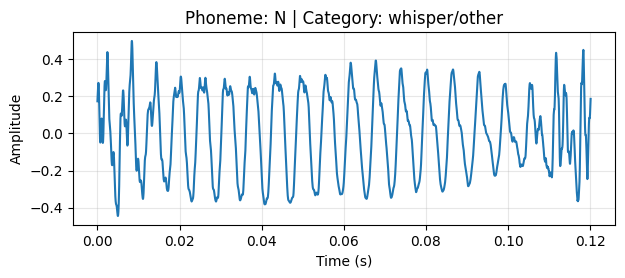

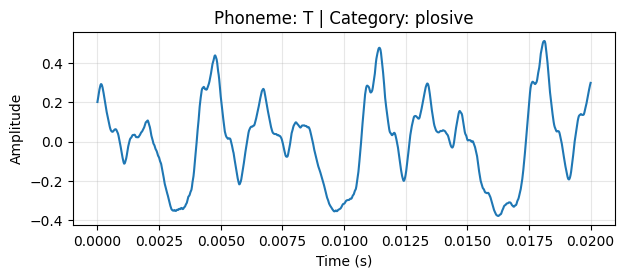

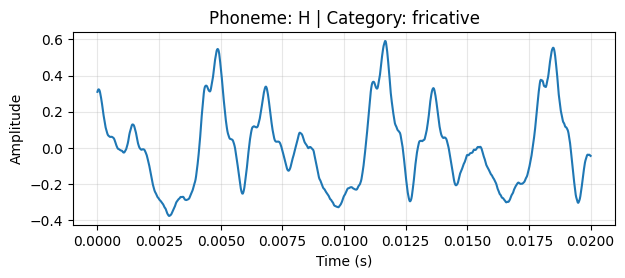

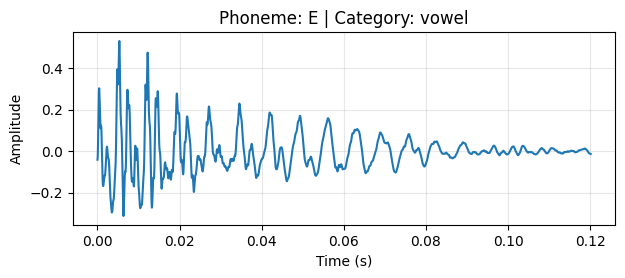

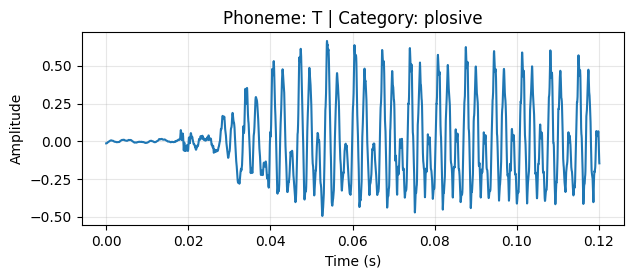

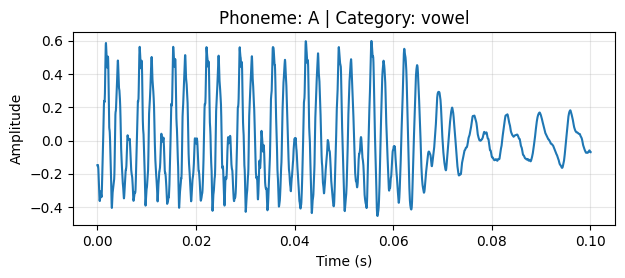

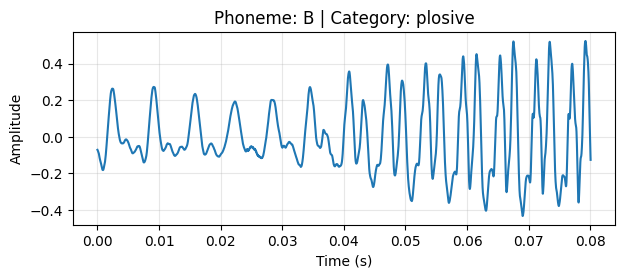

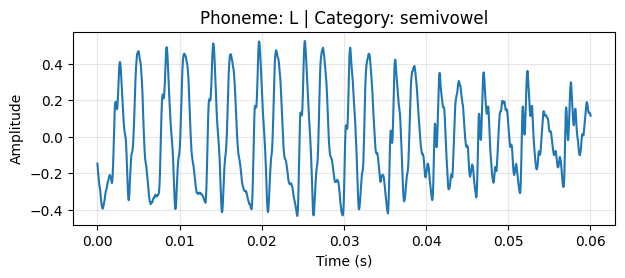

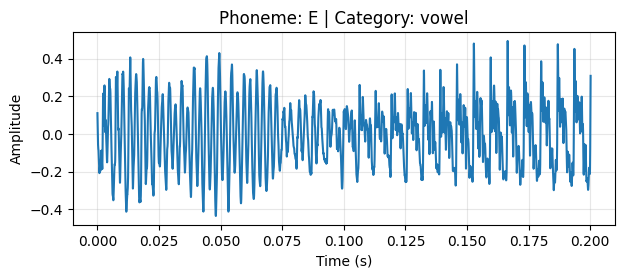

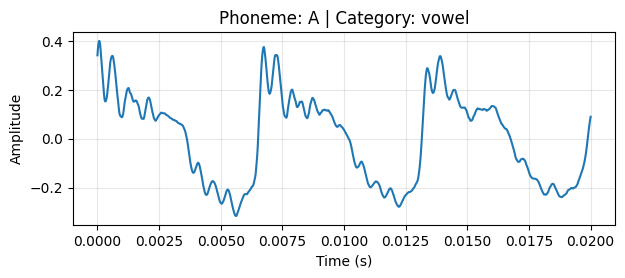

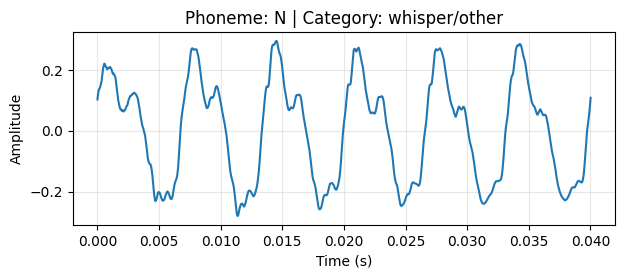

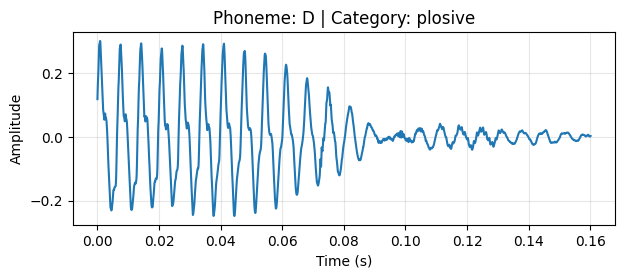

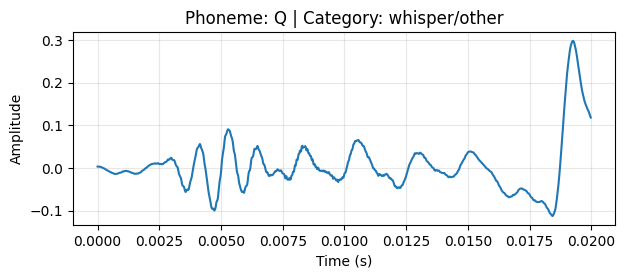

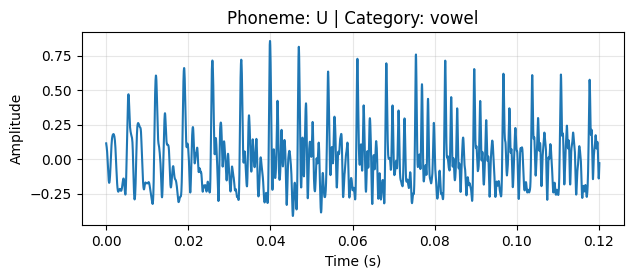

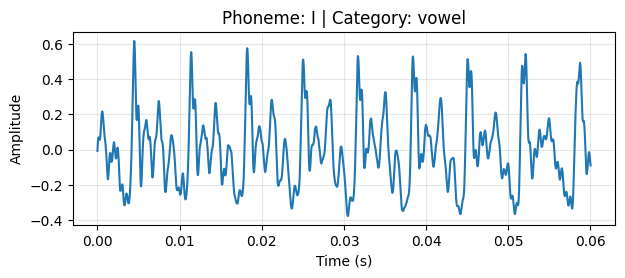

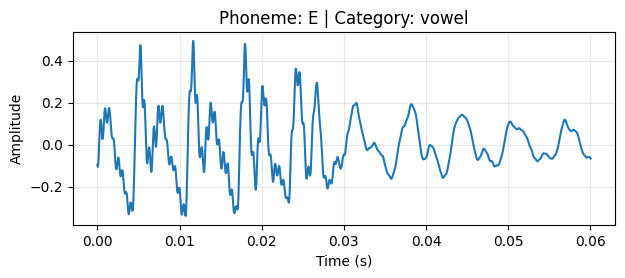

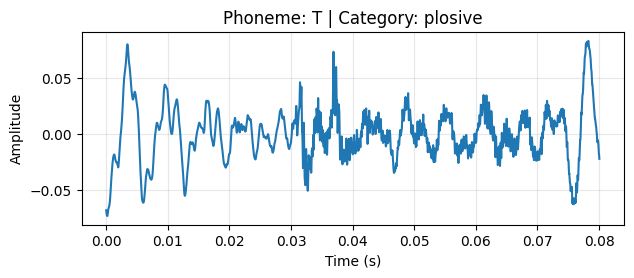

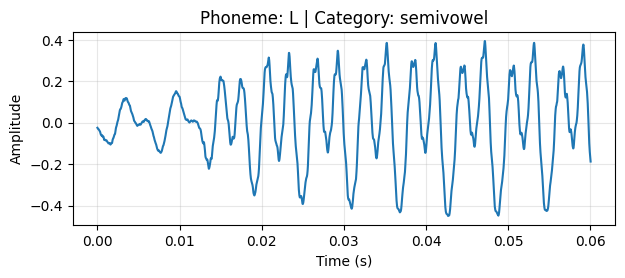

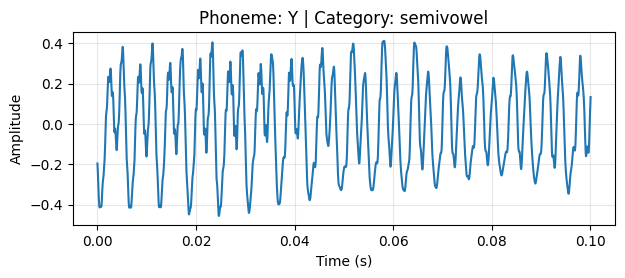

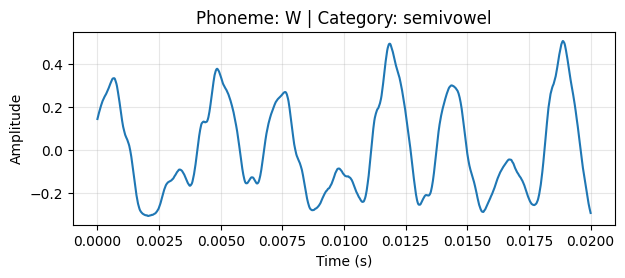

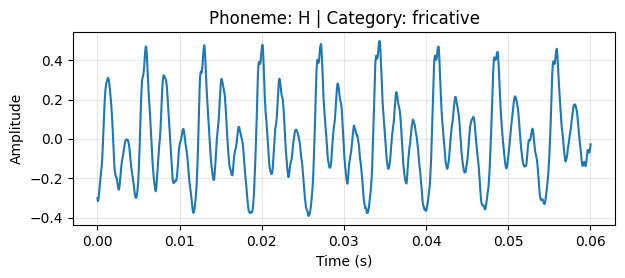

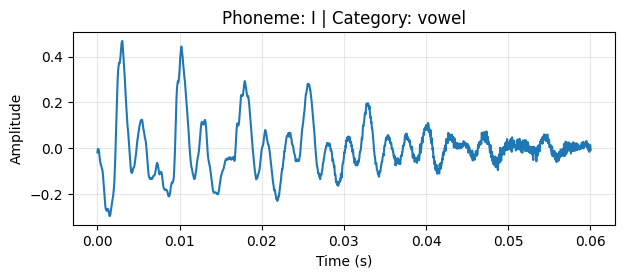

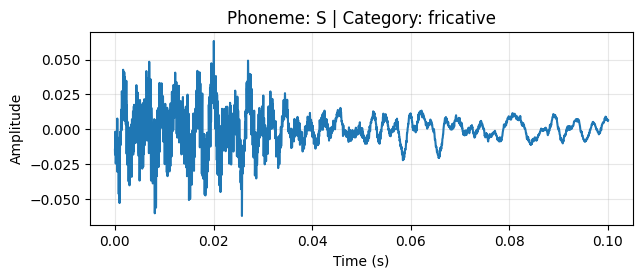

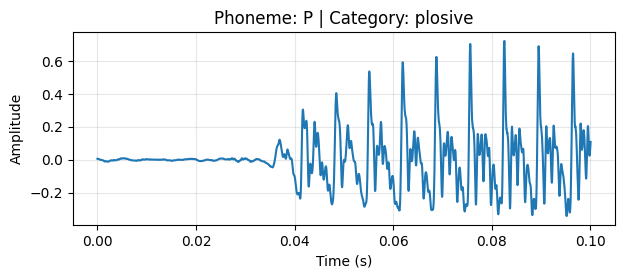

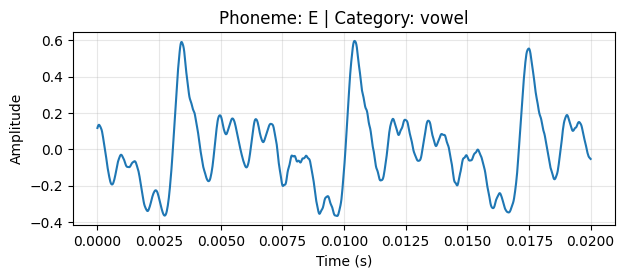

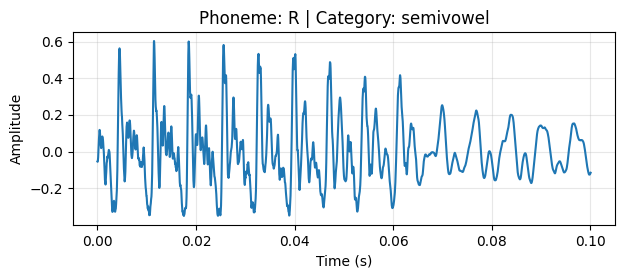

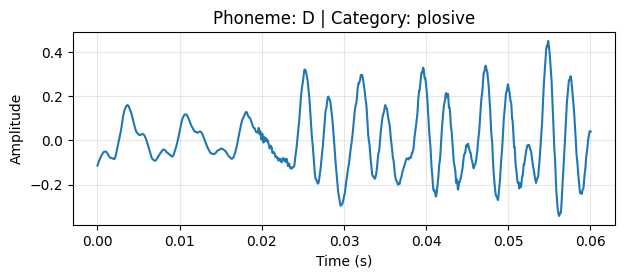

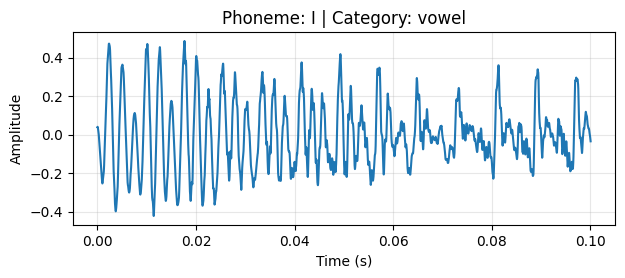

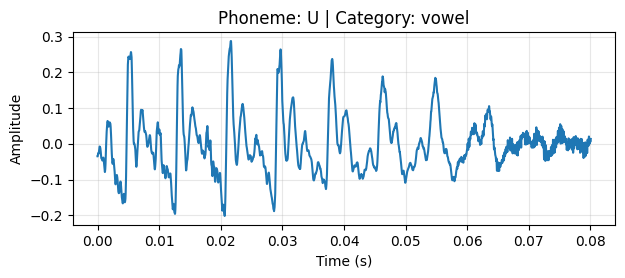

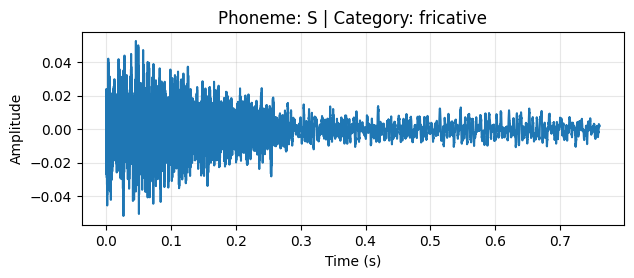

In [21]:
def plot_phoneme(segment, sr, phoneme, category):
    t = np.arange(len(segment)) / sr
    plt.figure(figsize=(7,2.5))
    plt.plot(t, segment)
    plt.title(f"Phoneme: {phoneme} | Category: {category}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.3)
    plt.show()

for p in phoneme_intervals:
    segment = waveform[0, p["start_sample"]:p["end_sample"]].numpy()
    plot_phoneme(segment, sample_rate, p["phoneme"], p["category"])

## 9. Voiced vs Unvoiced Comparison

Voiced segment: Phoneme 'E' (Category: vowel)


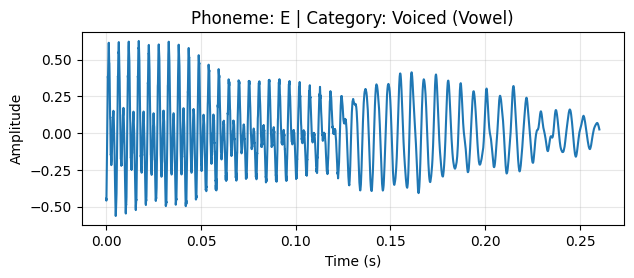

Unvoiced segment: Phoneme 'S' (Category: fricative)


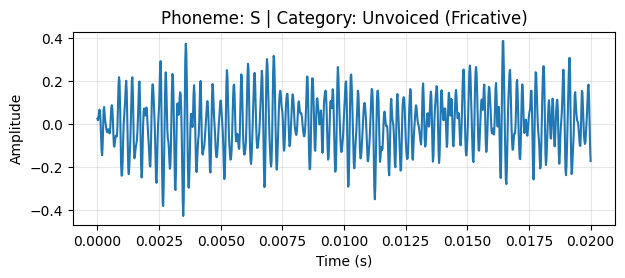

In [22]:
def get_category(p):
    vowels = ['A', 'E', 'I', 'O', 'U']
    fricatives = ['S', 'F', 'Z', 'H']
    char = p["phoneme"].upper()
    if char in vowels: return "vowel"
    if char in fricatives: return "fricative"
    return "other"

voiced = next((p for p in phoneme_intervals if get_category(p) == "vowel"), None)
unvoiced = next((p for p in phoneme_intervals if get_category(p) == "fricative"), None)

if voiced and unvoiced:
    print(f"Voiced segment: Phoneme '{voiced['phoneme']}' (Category: {voiced['category']})")
    plot_phoneme(
        waveform[0, voiced["start_sample"]:voiced["end_sample"]].numpy(),
        sample_rate,
        voiced["phoneme"],
        "Voiced (Vowel)"
    )

    print(f"Unvoiced segment: Phoneme '{unvoiced['phoneme']}' (Category: {unvoiced['category']})")
    plot_phoneme(
        waveform[0, unvoiced["start_sample"]:unvoiced["end_sample"]].numpy(),
        sample_rate,
        unvoiced["phoneme"],
        "Unvoiced (Fricative)"
    )
else:
    print("Error: Could not find both a voiced and unvoiced segment.")
    print("Detected letters:", [p['phoneme'] for p in phoneme_intervals])

## Comparison Analysis

**Observed differences between voiced and unvoiced phonemes:**

**Periodicity:**
- Voiced phonemes (vowels) show clear periodic patterns in the waveform due to regular vocal fold vibration
- Unvoiced phonemes (fricatives) display aperiodic, random fluctuations with no repeating pattern

**Amplitude patterns:**
- Voiced phonemes have more consistent amplitude with smooth envelope
- Unvoiced phonemes show irregular amplitude variations typical of turbulent airflow

**Presence or absence of noise-like structure:**
- Voiced phonemes: Absence of noise-like structure; waveform shows harmonic content
- Unvoiced phonemes: Strong noise-like structure; waveform resembles random noise from turbulent air passing through constriction

## Objective 2

 To analyze fricative and approximant speech sounds and infer airflow turbulence
characteristics.  
Record the sentence: “She sees you.”  
Perform the following:
- Record the given sentence at a sampling rate of 16 kHz, mono WAV format. Load the recorded
speech signal.
- Identify regions corresponding to fricatives and approximants.
- Use the segmentation approach implemented in the previous lab to automatically extract
phoneme-level segments.
- Isolate segments corresponding to fricatives (/s/, /ʃ/, /z/) and approximants (/j/).
- Plot the waveform of each extracted fricative and approximant segment.
- Observe qualitative differences in waveform smoothness, amplitude continuity, presence of
noise-like fluctuations.
- Based on waveform observations, infer conceptually whether the airflow is turbulent
(associated with higher effective Reynolds number) or Smooth/laminar (associated with lower
effective Reynolds number).
- Compare fricatives and approximants in terms of waveform irregularity, periodicity, energy
variation. Relate the observations to articulatory constriction differences.

In [23]:
import os
import librosa
import torch

# Preserve Objective 1 references before loading a new recording
phoneme_intervals_obj1 = [dict(p) for p in phoneme_intervals]
waveform_obj1 = waveform.clone()
sample_rate_obj1 = sample_rate

audio_filename = "voice2.wav"
# Sentence: "She sees you."

if not os.path.exists(audio_filename):
    print(f"Error: '{audio_filename}' not found. Please upload 'sentence2.wav' to the Colab files tab.")
else:
    data, sr = librosa.load(audio_filename, sr=16000)
    waveform_obj2 = torch.from_numpy(data).unsqueeze(0)
    sample_rate_obj2 = 16000

    waveform_obj2 = waveform_obj2 / torch.max(torch.abs(waveform_obj2))
    print(f"Successfully loaded {audio_filename} at {sample_rate_obj2}Hz")

Successfully loaded voice2.wav at 16000Hz


## 11. Repeat Phoneme Recognition

In [24]:
input_values = processor(
    waveform_obj2[0].numpy(),
    sampling_rate=sample_rate_obj2,
    return_tensors="pt"
).input_values

with torch.no_grad():
    logits = model(input_values).logits

predicted_ids = torch.argmax(logits, dim=-1)

In [25]:
target_sampling_rate = 16000

if sample_rate_obj2 != target_sampling_rate:
    waveform_np = waveform_obj2[0].numpy()
    waveform_resampled = librosa.resample(waveform_np, orig_sr=sample_rate_obj2, target_sr=target_sampling_rate)
    input_sr = target_sampling_rate
else:
    waveform_resampled = waveform_obj2[0].numpy()
    input_sr = sample_rate_obj2

input_values = processor(
    waveform_resampled,
    sampling_rate=input_sr,
    return_tensors="pt"
).input_values

with torch.no_grad():
    logits = model(input_values).logits

predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.decode(predicted_ids[0])

print("Recognized Phoneme Sequence:")
print(transcription)

Recognized Phoneme Sequence:
SHE TE TEU


In [26]:
predicted_tokens_obj2 = predicted_ids[0].numpy()
time_step_obj2 = waveform_obj2.shape[1] / logits.shape[1] / sample_rate_obj2

phoneme_intervals_obj2 = []
current_phoneme = None
start_idx = 0

for idx, token_id in enumerate(predicted_tokens_obj2):
    phoneme_char = processor.decode([int(token_id)]).strip()

    if phoneme_char and phoneme_char != current_phoneme:
        if current_phoneme is not None:
            phoneme_intervals_obj2.append({
                'phoneme': current_phoneme,
                'start_sample': int(start_idx * time_step_obj2 * sample_rate_obj2),
                'end_sample': int(idx * time_step_obj2 * sample_rate_obj2)
            })
        current_phoneme = phoneme_char
        start_idx = idx

if current_phoneme is not None:
    phoneme_intervals_obj2.append({
        'phoneme': current_phoneme,
        'start_sample': int(start_idx * time_step_obj2 * sample_rate_obj2),
        'end_sample': waveform_obj2.shape[1]
    })

for p in phoneme_intervals_obj2:
    p['category'] = phoneme_categories.get(p['phoneme'].upper(), 'whisper/other')

print(f"Detected {len(phoneme_intervals_obj2)} phoneme segments for Objective 2")

Detected 8 phoneme segments for Objective 2


## 13. Plot Fricatives & Approximants Only

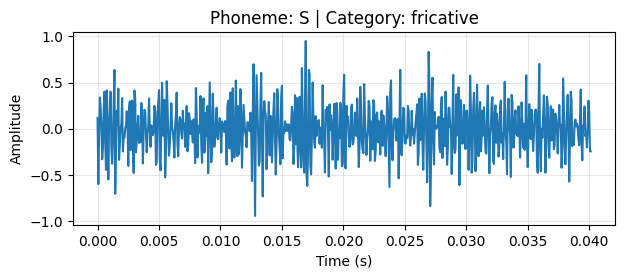

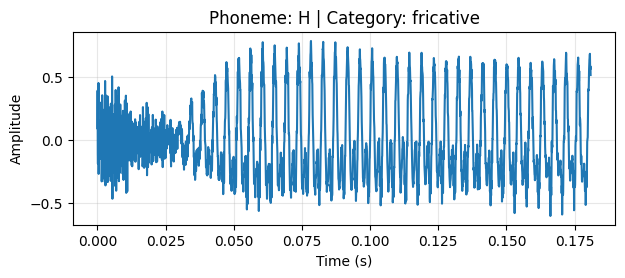

In [27]:
for p in phoneme_intervals_obj2:
    category = p.get("category", "other")

    if category in ["fricative", "semivowel"]:
        segment = waveform_obj2[0, p["start_sample"]:p["end_sample"]].numpy()
        plot_phoneme(segment, sample_rate_obj2, p["phoneme"], category)